In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,   roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
import torch
import torch.nn as nn

In [2]:
# Data
raw_X = np.array([
    [500, 2, 22], [3500, 8, 45], [800, 3, 28],
    [4500, 9, 50], [300, 1, 19], [5000, 10, 55],
    [1200, 4, 31], [3800, 8, 42], [600, 2, 25],
    [4200, 9, 48], [900, 3, 29], [4800, 9, 44],
    [1500, 4, 33], [5500, 8, 52], [400, 1, 21],
    [6000, 10, 58], [1800, 5, 35], [4100, 8, 46],
    [700, 2, 23], [3200, 7, 40]
])

raw_y = np.array([[1],[0],[1],[0],[1],[0],[1],[0],[1],[0],
                  [1],[0],[1],[0],[1],[0],[1],[0],[1],[0]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_X)

X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(raw_y)

print("Data ready!")

Data ready!


In [3]:
class OrderNN(nn.Module):
    def __init__(self):
        super(OrderNN, self).__init__()
        self.layer1 = nn.Linear(3, 8)
        self.layer2 = nn.Linear(8, 4)
        self.layer3 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

model = OrderNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


losses = []
epochs = 300

for epoch in range(epochs):
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    if epoch   % 50 == 0:
        print(f"Epoch{epoch}/{epochs} - Loss: {loss.item():.4f}")

print("Training complete!")

Epoch0/300 - Loss: 0.6885
Epoch50/300 - Loss: 0.0525
Epoch100/300 - Loss: 0.0051
Epoch150/300 - Loss: 0.0024
Epoch200/300 - Loss: 0.0015
Epoch250/300 - Loss: 0.0010
Training complete!


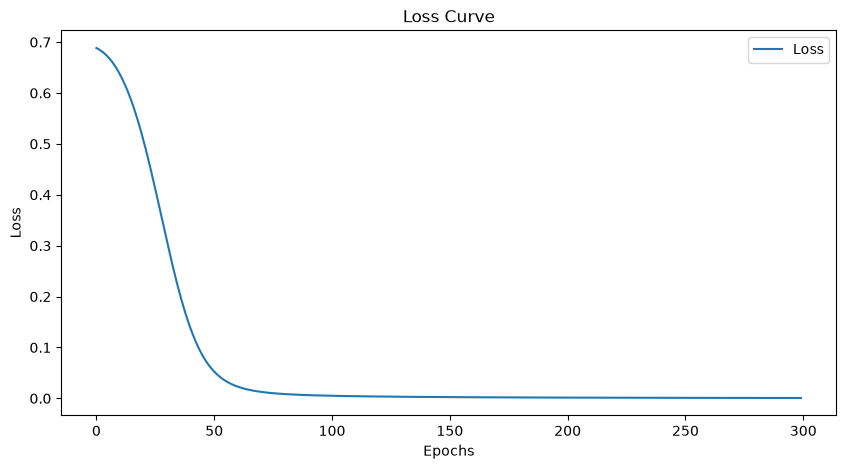

In [4]:
# loss curve chart
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), losses, label='Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [5]:
model.eval()
new_order = np.array([[2000,4,30]])  # apni values daalo
with torch.no_grad():
    new_order_scaled = scaler.transform(new_order)
    new_order_tensor = torch.FloatTensor(new_order_scaled)
    prediction = model(new_order_tensor)
    print(f"Predicted probability of order being placed: {prediction.item():.4f}")

Predicted probability of order being placed: 0.9991


In [6]:
def train_model(epochs):
    model = OrderNN()
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(epochs):
        pred = model(X_tensor)
        loss = criterion(pred, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    final_loss = loss.item()
    return final_loss

# Alag alag epochs try karo
for ep in [50, 100, 200, 300, 500]:
    loss = train_model(ep)
    print(f"Epochs {ep:4d} → Final Loss: {loss:.4f}")

Epochs   50 → Final Loss: 0.0213
Epochs  100 → Final Loss: 0.0046
Epochs  200 → Final Loss: 0.0014
Epochs  300 → Final Loss: 0.0441
Epochs  500 → Final Loss: 0.0297


Epoch  20 | Loss: 0.4817
Epoch  40 | Loss: 0.2772
Epoch  60 | Loss: 0.1354
Epoch  80 | Loss: 0.0587
Epoch 100 | Loss: 0.0296

Start Loss: 0.6642
Final Loss: 0.0296


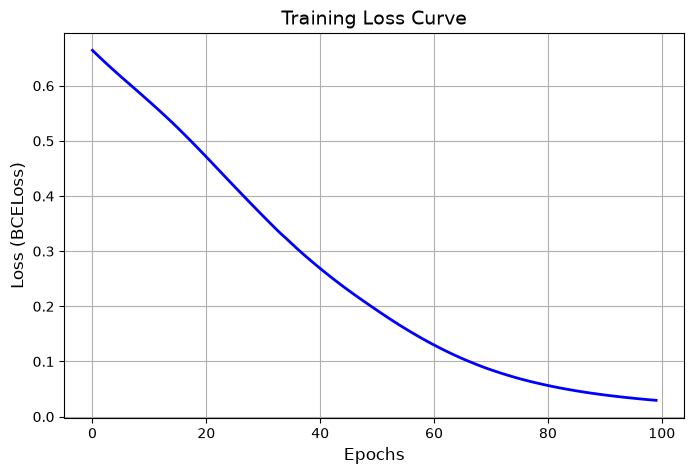

In [7]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import numpy as np

# Seed Fix
torch.manual_seed(42)
np.random.seed(42)

# Data (Customer Churn: 5 Customers, 3 Features)
raw_X = np.array([
    [30.0, 100.0, 2.0],  # Age, Monthly Bill, Support Calls -> Churned (1)
    [22.0, 30.0,  0.0],  # Retained (0)
    [45.0, 120.0, 4.0],  # Churned (1)
    [25.0, 45.0,  1.0],  # Retained (0)
    [50.0, 110.0, 5.0]   # Churned (1)
])

raw_y = np.array([[1.0], [0.0], [1.0], [0.0], [1.0]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_X)
X_train = torch.FloatTensor(X_scaled)
y_train = torch.FloatTensor(raw_y)

# Model
class ChurnPredictor(nn.Module):
    def __init__(self):
        super(ChurnPredictor, self).__init__()
        self.layer1 = nn.Linear(3, 8)
        self.layer2 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

model = ChurnPredictor()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# LOSS CURVE TRACKING & EPOCHS TUNING
# ==========================================
loss_history = []
epochs = 100

for epoch in range(1, epochs + 1):
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    
    # BLANK 1: Loop ke andar 3 training steps likhein
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # BLANK 2: Current loss.item() ko loss_history list mein add karein
    loss_history.append(loss.item())
    
    # BLANK 3: Har 20 epochs baad loss print karein
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")


# BLANK 4: Pehle epoch ki loss aur aakhri (100th) epoch ki loss print karein
print(f"\nStart Loss: {loss_history[0]:.4f}")
print(f"Final Loss: {loss_history[-1]:.4f}")



plt.figure(figsize=(8, 5))             # Graph ka size fix karein
plt.plot(loss_history, color='blue', linewidth=2)  # Line draw karein

plt.title('Training Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (BCELoss)', fontsize=12)
plt.grid(True)                         # Grid lines dikhane ke liye

plt.show()

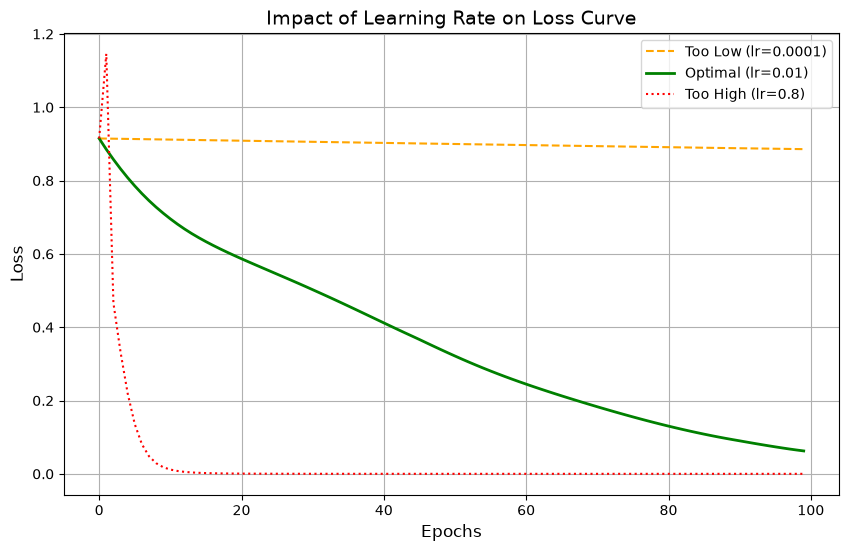

In [8]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Seed Fix
torch.manual_seed(42)
np.random.seed(42)

# Data Setup
raw_X = np.array([[30.0, 100.0], [22.0, 30.0], [45.0, 120.0], [25.0, 45.0], [50.0, 110.0]])
raw_y = np.array([[1.0], [0.0], [1.0], [0.0], [1.0]])

scaler = StandardScaler()
X_train = torch.FloatTensor(scaler.fit_transform(raw_X))
y_train = torch.FloatTensor(raw_y)

# Function jo alag alag Learning Rate par train karke loss record karega
def train_with_lr(lr_value):
    torch.manual_seed(42)  # Same starting point har experiment ke liye
    model = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_value)
    
    history = []
    for _ in range(100):
        predictions = model(X_train)
        loss = criterion(predictions, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append(loss.item())
    return history

# 3 Alag Learning Rates Par Test:
loss_low = train_with_lr(lr_value=0.0001)  # Too Low
loss_good = train_with_lr(lr_value=0.01)    # Good / Optimal
loss_high = train_with_lr(lr_value=0.8)    # Too High

# ==========================================
# GRAPH PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(loss_low, label='Too Low (lr=0.0001)', color='orange', linestyle='--')
plt.plot(loss_good, label='Optimal (lr=0.01)', color='green', linewidth=2)
plt.plot(loss_high, label='Too High (lr=0.8)', color='red', linestyle=':')

plt.title('Impact of Learning Rate on Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.show()

Epoch 30/120 - Loss: 0.1438
Epoch 60/120 - Loss: 0.0310
Epoch 90/120 - Loss: 0.0115
Epoch 120/120 - Loss: 0.0062

New Customer Purchase Chance: 91.69%
Start Loss: 0.6454
Final Loss: 0.0062


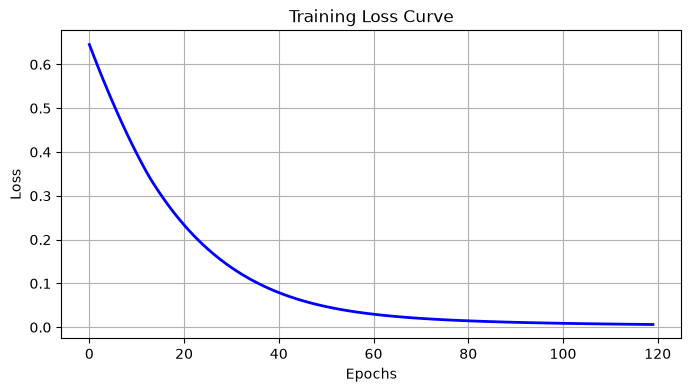

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Seed Fix
torch.manual_seed(42)
np.random.seed(42)

# Data Setup
raw_X = np.array([
    [15.0, 8.0, 3.0],   # Customer 1 -> Purchased (1.0)
    [2.0,  1.0, 0.0],   # Customer 2 -> Left (0.0)
    [20.0, 12.0, 4.0],  # Customer 3 -> Purchased (1.0)
    [3.0,  2.0, 0.0],   # Customer 4 -> Left (0.0)
    [18.0, 10.0, 2.0],  # Customer 5 -> Purchased (1.0)
    [1.0,  1.0, 0.0]    # Customer 6 -> Left (0.0)
])

raw_y = np.array([
    [1.0], [0.0], [1.0], [0.0], [1.0], [0.0]
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_X)
X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(raw_y)

# Model Class
class PurchasePredictor(nn.Module):
    def __init__(self):
        super(PurchasePredictor, self).__init__()
        self.layer1 = nn.Linear(3, 10)
        self.layer2 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

# FIXED 1: Model ko loop se pehle EK BAAR create karein
model = PurchasePredictor()
# Model ko train karte waqt use karein
criterion = nn.BCELoss()
# FIXED 2: Pehle se banaye hue 'model' variable ke parameters pass karein
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# FIXED 3: Epochs ko 120 set karein
epochs = 120
# FIXED 4: Loss history ko initialize karein
loss_history = []
# FIXED 5: Loss history ko update karein
for epoch in range(1, epochs + 1):
    # Model train ho raha hai (nayi instance nahi ban rahi)
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    # Loss history ko update karein
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Loss history ko update karein
    loss_history.append(loss.item())
    # BLANK 3: Har 30 epochs baad loss print karein
    if epoch % 30 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {loss.item():.4f}")

# Prediction on New Customer
model.eval()
new_customer_raw = np.array([[12.0, 6.0, 2.0]])
# New customer data ko scale karein
with torch.no_grad():
    new_customer_scaled = scaler.transform(new_customer_raw)
    new_customer_tensor = torch.FloatTensor(new_customer_scaled)
    buy_chance = model(new_customer_tensor).item()
# Print the purchase chance
print(f"\nNew Customer Purchase Chance: {buy_chance * 100:.2f}%")
print(f"Start Loss: {loss_history[0]:.4f}")
print(f"Final Loss: {loss_history[-1]:.4f}")

# Graph
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()